In [1]:
#Plot Bar Chart
import pandas as pd
from plotter_rev import generate_plots
from config import progress_status_order, assignment_status_order

survey_collection_df = pd.read_csv('outputs/csv/survey_collection_deadline_adjusted.csv')
report_assignment_df = pd.read_csv('outputs/csv/report_assignment.csv')

In [2]:
anomali_df = pd.read_csv('input/anomali.csv', sep=";")
anomali_df.head()

,kd_kab,name,type,OPEN
0,9409,IMK Tahunan 2025 - Anomali,progress,167
1,9419,IMK Tahunan 2025 - Anomali,progress,31
2,9428,IMK Tahunan 2025 - Anomali,progress,1
3,9471,IMK Tahunan 2025 - Anomali,progress,108
4,9501,IMK Tahunan 2025 - Anomali,progress,40


In [3]:
report_assignment_df = pd.concat([report_assignment_df, anomali_df], ignore_index=True)

survey_collection_df.loc[len(survey_collection_df)] = {"name": "IMK Tahunan 2025 - Anomali", "endDate": "2025-11-17", "startDate": "2025-11-1"}

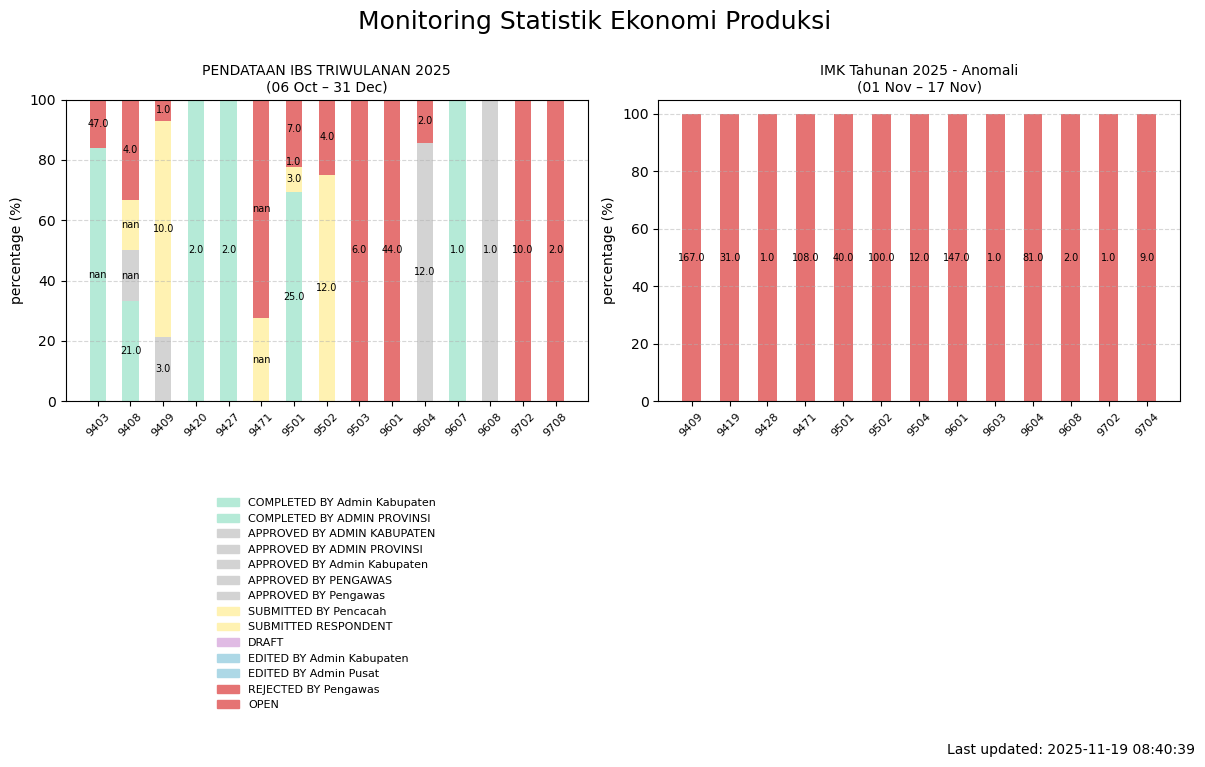

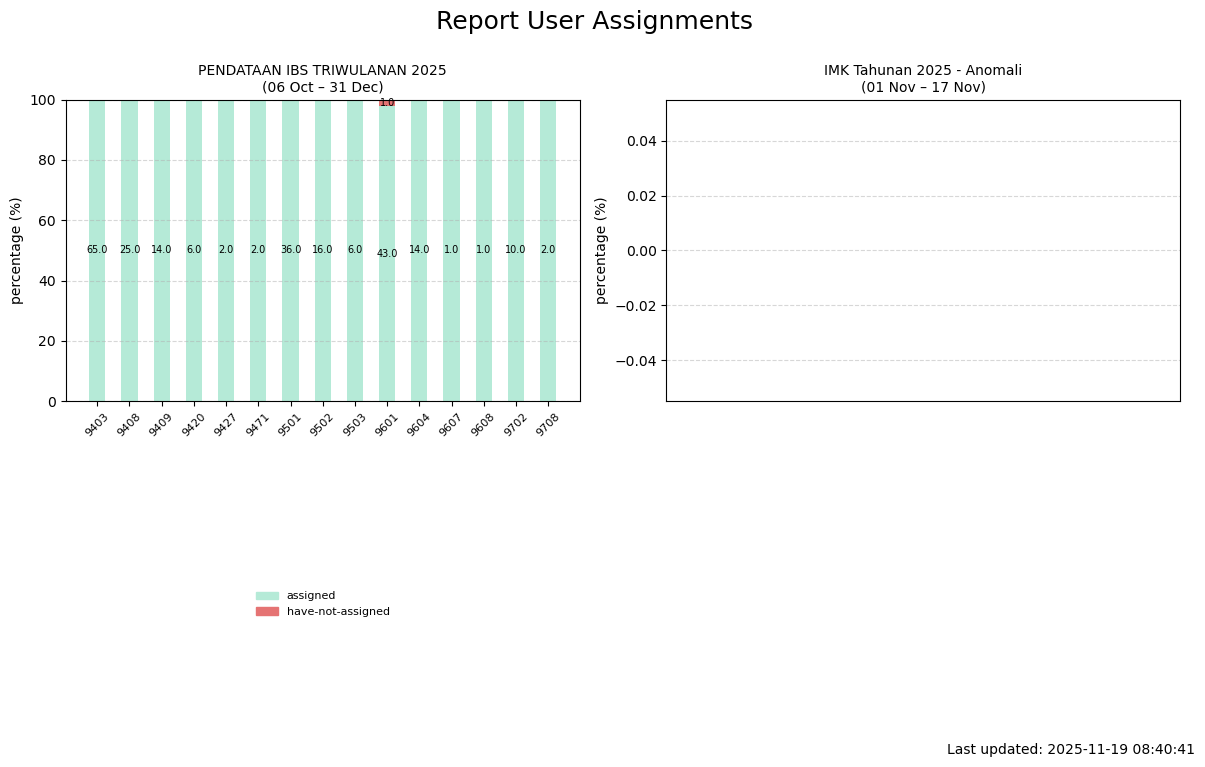

In [4]:
progress_assignment_df = report_assignment_df[report_assignment_df['type'] == "progress"].copy()
user_assignment_df = report_assignment_df[report_assignment_df['type'] != "progress"].copy() 
generate_plots(progress_assignment_df, survey_collection_df, progress_status_order, 1)   
generate_plots(user_assignment_df, survey_collection_df, assignment_status_order, 2)

# One chart

In [5]:
report_assignment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   kd_kab                        559 non-null    int64  
 1   total                         546 non-null    float64
 2   COMPLETED BY Admin Kabupaten  150 non-null    float64
 3   OPEN                          137 non-null    float64
 4   EDITED BY Admin Kabupaten     5 non-null      float64
 5   prov_id                       546 non-null    float64
 6   name                          559 non-null    object 
 7   time_stamp                    546 non-null    object 
 8   type                          559 non-null    object 
 9   APPROVED BY Pengawas          45 non-null     float64
 10  REJECTED BY Pengawas          6 non-null      float64
 11  SUBMITTED BY Pencacah         16 non-null     float64
 12  APPROVED BY ADMIN KABUPATEN   33 non-null     float64
 13  DRAFT

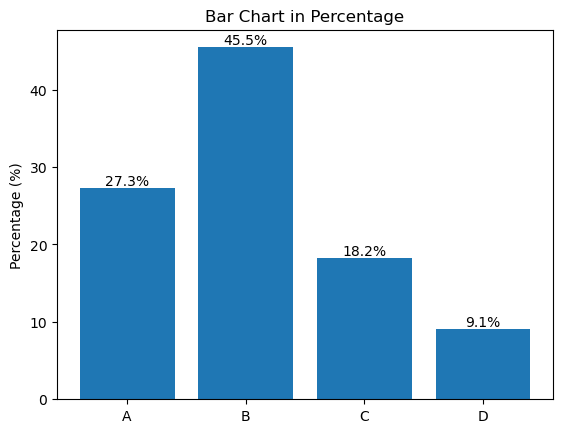

In [6]:
import matplotlib.pyplot as plt

categories = ["A", "B", "C", "D"]
values = [30, 50, 20, 10]

# Hitung persentase
total = sum(values)
percentages = [v / total * 100 for v in values]

fig, ax = plt.subplots()
bars = ax.bar(categories, percentages)

# Tambahkan label persentase
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_ylabel("Percentage (%)")
ax.set_title("Bar Chart in Percentage")

plt.show()